# Employee Attrition Prediction
**Goal:** Predict which employees are likely to leave so HR 
can intervene proactively.

**Dataset:** IBM HR Analytics — 1470 employees, 13 features

**Best Model:** Logistic Regression (C=0.01) — 0.68 Recall (5-fold CV)

In [107]:
# core liberaries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
# Machine learning 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

# settings

import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

### LOAD DATA 

In [108]:
df = pd.read_csv('IBM.csv')
df.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


#### EXPLORATORY DATA ANALYSIS

In this stage the data is explored and analysed properly to get helpful insights from the data which will help us.

In [109]:
df.shape

(1470, 13)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Department               1470 non-null   object
 3   DistanceFromHome         1470 non-null   int64 
 4   Education                1470 non-null   int64 
 5   EducationField           1470 non-null   object
 6   EnvironmentSatisfaction  1470 non-null   int64 
 7   JobSatisfaction          1470 non-null   int64 
 8   MaritalStatus            1470 non-null   object
 9   MonthlyIncome            1470 non-null   int64 
 10  NumCompaniesWorked       1470 non-null   int64 
 11  WorkLifeBalance          1470 non-null   int64 
 12  YearsAtCompany           1470 non-null   int64 
dtypes: int64(9), object(4)
memory usage: 149.4+ KB


### This is the Attrtition Distribution

The data is heavily imbalanced towards NO. and due to several reasons we can't perform undersampling then most of the important information will get vanished.
we will see about it later during model training , what can we do about it 

In [111]:
df['Attrition'].value_counts()
df['Attrition'].value_counts(normalize = True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

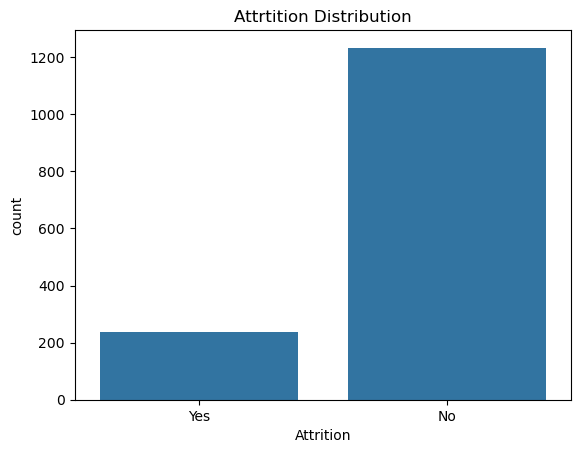

In [112]:
sns.countplot(x = 'Attrition' , data = df)
plt.title('Attrtition Distribution')
plt.show()

### Key observations from df.describe()
Four columns showed high standard deviation relative to mean:
- **MonthlyIncome** — std (4707) nearly as large as mean (6502), 
  high income inequality
- **YearsAtCompany** — std (6.1) close to mean (7.0), median only 5, 
  max 40 — most employees are relatively new, few long-tenure outliers
- **DistanceFromHome** — std (8.1) relative to mean (9.2), 
  high variation in commute distances
- **Age** — std of 9.1, wide age range across workforce

These columns were flagged for deeper investigation against 
the target variable.

In [113]:
df.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.728571,6502.931293,2.693197,2.761224,7.008163
std,9.135373,8.106864,1.024165,1.093082,1.102846,4707.956783,2.498009,0.706476,6.126525
min,18.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,1.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,2911.000000,1.000000,2.000000,3.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,4919.000000,2.000000,3.000000,5.000000
75%,43.000000,14.000000,4.000000,4.000000,4.000000,8379.000000,4.000000,3.000000,9.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,19999.000000,9.000000,4.000000,40.000000


In [114]:
categories = df.select_dtypes(include = 'object').columns.tolist()
numereical = df.select_dtypes(include = 'int64').columns.tolist()

In [115]:
print('Categorical columns : ',categories)

print('-'*150)
print('Numerical columns: ',numereical)


Categorical columns :  ['Attrition', 'Department', 'EducationField', 'MaritalStatus']
------------------------------------------------------------------------------------------------------------------------------------------------------
Numerical columns:  ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'WorkLifeBalance', 'YearsAtCompany']


In [116]:
df.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

Insight :

Employees who left earned on average 30% less than employees who stayed , suggesting income is a strong predictor of attrition

In [117]:
cols_to_check = ['DistanceFromHome','EnvironmentSatisfaction','JobSatisfaction','NumCompaniesWorked','WorkLifeBalance']

for col in cols_to_check:
    print(f'{col}: ')
    print(df.groupby('Attrition')[col].mean())
    print('-'*40)

DistanceFromHome: 
Attrition
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64
----------------------------------------
EnvironmentSatisfaction: 
Attrition
No     2.771290
Yes    2.464135
Name: EnvironmentSatisfaction, dtype: float64
----------------------------------------
JobSatisfaction: 
Attrition
No     2.778589
Yes    2.468354
Name: JobSatisfaction, dtype: float64
----------------------------------------
NumCompaniesWorked: 
Attrition
No     2.645580
Yes    2.940928
Name: NumCompaniesWorked, dtype: float64
----------------------------------------
WorkLifeBalance: 
Attrition
No     2.781022
Yes    2.658228
Name: WorkLifeBalance, dtype: float64
----------------------------------------


In [118]:
df.groupby('Attrition')['Age'].mean()

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

Insights:

1. Quitters lived further from office on average
2. Lower job and environment satisfaction strongly 
   associated with attrition
3. Employees with more previous companies are more 
   likely to leave again
4. Slightly poorer work-life balance among those who left
5. Younger employees leave more — average age 33 for quitters vs 37 for stayers.


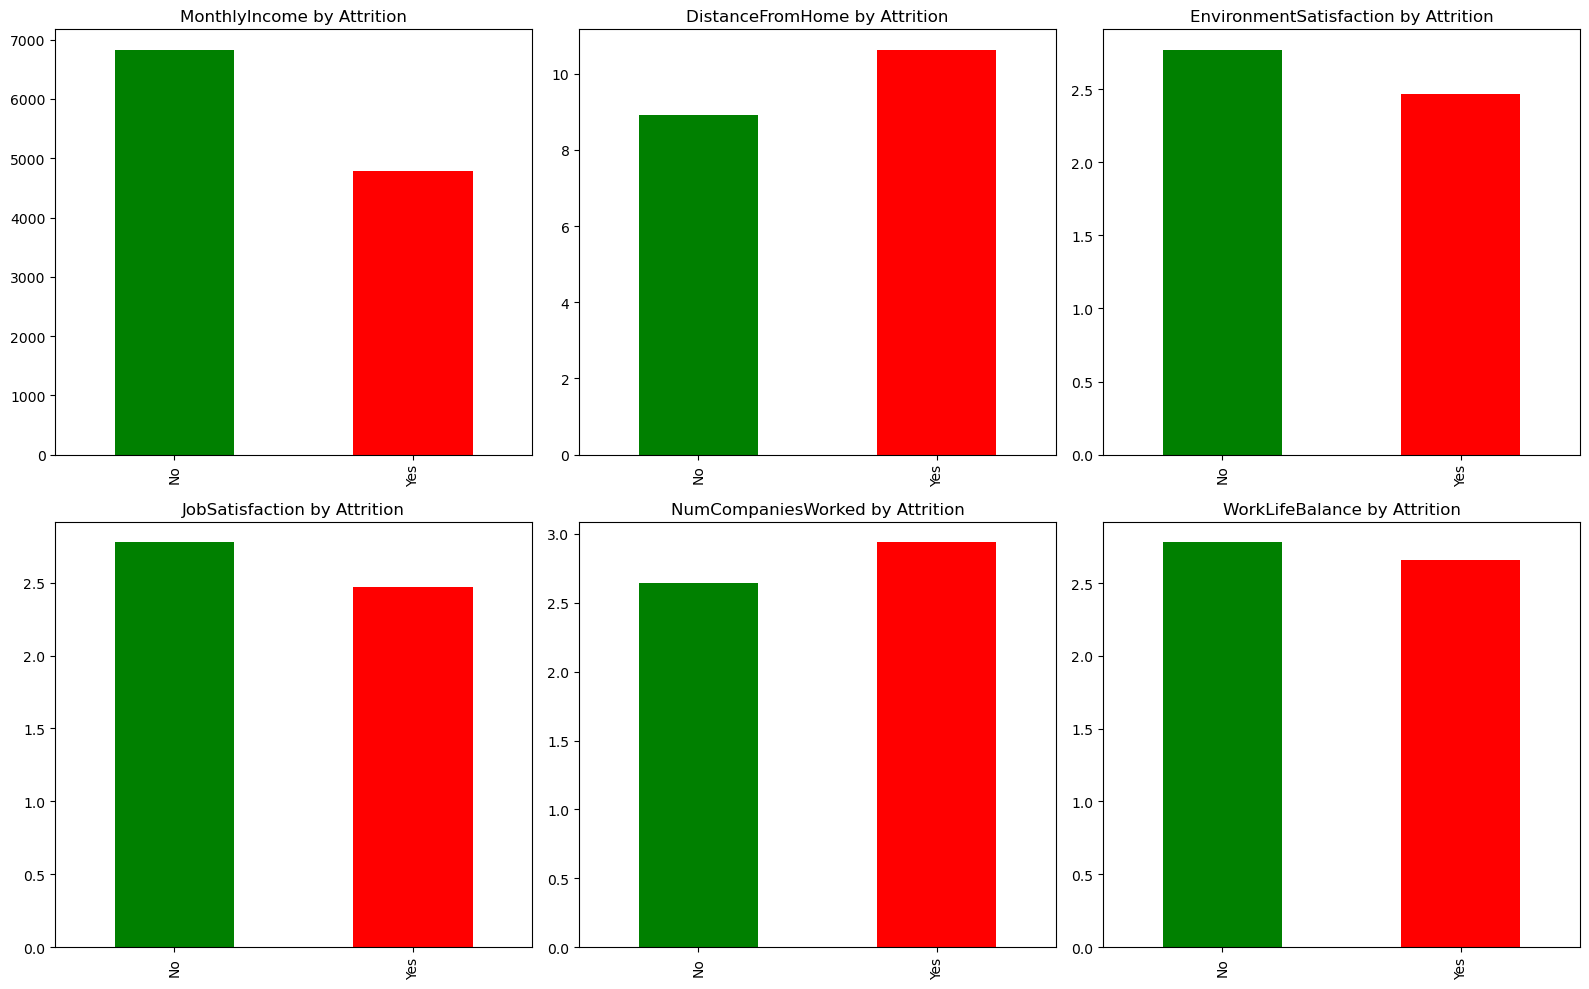

In [119]:
cols = ['MonthlyIncome','DistanceFromHome','EnvironmentSatisfaction','JobSatisfaction','NumCompaniesWorked','WorkLifeBalance']

fig , axes = plt.subplots(2,3 , figsize = (16,10))

for i , col in enumerate(cols):
    ax = axes[i//3][i%3]
    df.groupby('Attrition')[col].mean().plot(kind = 'bar' , ax = ax, color =['green','red'])
    ax.set_title(f'{col} by Attrition')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

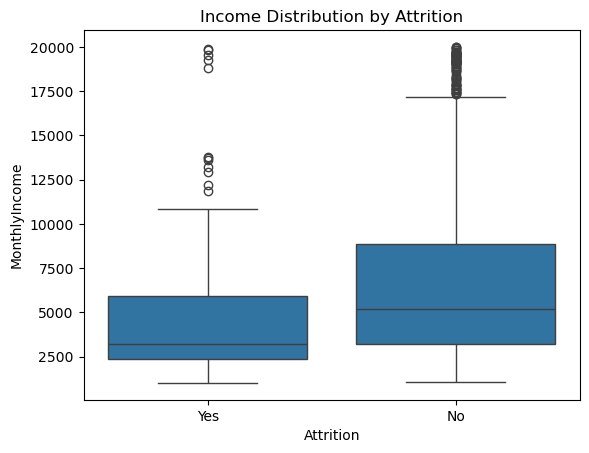

In [120]:
sns.boxplot(x = 'Attrition' , y = 'MonthlyIncome' ,data = df)
plt.title('Income Distribution by Attrition')
plt.show()

Most quitters are clustered in low income. But a few high earners (outliers above 12000) also left — meaning income alone doesn't explain everything. Other factors like satisfaction pushed those outliers out."

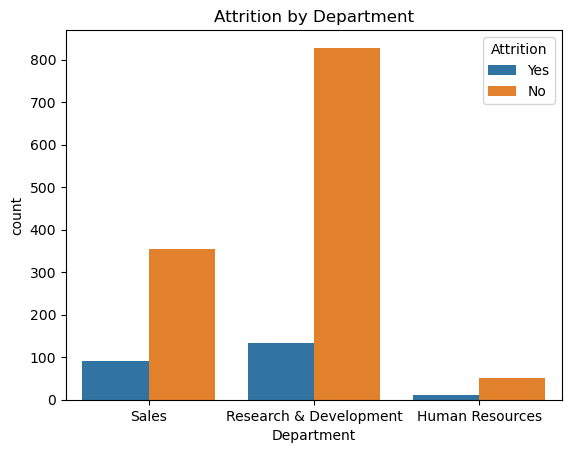

In [121]:
sns.countplot(x = 'Department' , hue = 'Attrition' , data = df)
plt.title('Attrition by Department')
plt.show()

In [122]:
pd.crosstab(df['Department'] , df['Attrition'] , normalize = 'index').mul(100).round(2)

Attrition,No,Yes
Department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63


**Key Insights from the above few cells**

Department-wise Attrition
Although the Research & Development department has the highest number of employees leaving, it also has the largest workforce.
After normalizing by department size (attrition rate), the Sales department has the highest attrition rate, followed by Human Resources, while Research & Development has the lowest attrition rate.
This demonstrates why attrition rate (%) provides a more meaningful comparison than raw employee counts.

Salary Distribution (Box Plot)
Employees who left generally have lower salaries, as indicated by the lower median and concentration of the distribution.
A few employees with relatively high salaries also left the company, appearing as outliers.
This suggests that salary alone does not explain attrition; other factors such as job satisfaction, career growth, overtime, work environment, or personal circumstances may also influence an employee's decision to leave.

In [123]:
df.groupby('Attrition')['Education'].mean()

Attrition
No     2.927007
Yes    2.839662
Name: Education, dtype: float64

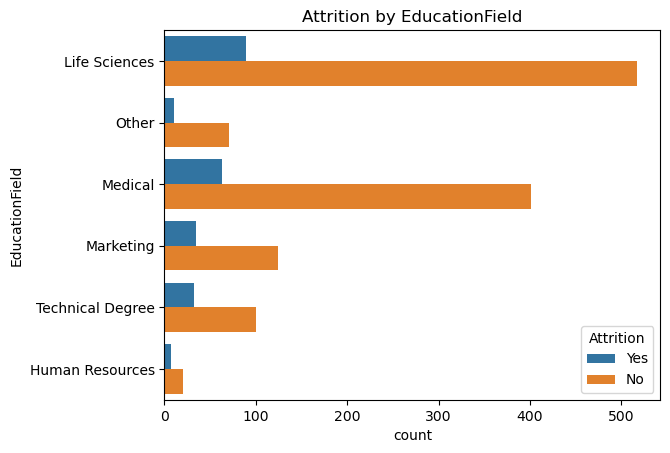

In [124]:
sns.countplot(y = 'EducationField' , hue = 'Attrition' , data = df)
plt.title('Attrition by EducationField')
plt.show()

In [125]:
print(df['EducationField'].unique())

['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']


In [126]:
pd.crosstab(df['EducationField'],df['Attrition'],normalize = 'index').mul(100).round(2)

Attrition,No,Yes
EducationField,,
Human Resources,74.07,25.93
Life Sciences,85.31,14.69
Marketing,77.99,22.01
Medical,86.42,13.58
Other,86.59,13.41
Technical Degree,75.76,24.24


In [127]:
pd.crosstab(df['MaritalStatus'] , df['Attrition'] , normalize = 'index').mul(100).round(2)

Attrition,No,Yes
MaritalStatus,,
Divorced,89.91,10.09
Married,87.52,12.48
Single,74.47,25.53


Single employees show highest attrition at 25.5%, 
nearly double that of married employees (12.5%). 
Marital status is a strong predictor — likely driven 
by differences in financial responsibility and 
risk tolerance.

# Cleaning Starts.

In [128]:
df.nunique()

Age                          43
Attrition                     2
Department                    3
DistanceFromHome             29
Education                     5
EducationField                6
EnvironmentSatisfaction       4
JobSatisfaction               4
MaritalStatus                 3
MonthlyIncome              1349
NumCompaniesWorked           10
WorkLifeBalance               4
YearsAtCompany               37
dtype: int64

In [129]:
df.columns.to_list()

['Age',
 'Attrition',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'NumCompaniesWorked',
 'WorkLifeBalance',
 'YearsAtCompany']

#### Feature Engineering 

Creating two new features with business logic:
- **IncomePerYear** = MonthlyIncome / Age — captures compensation 
  relative to career stage. A 45-year-old earning 3000 is far more 
  frustrated than a 25-year-old earning the same.
- **SatisfactionScore** = average of JobSatisfaction, 
  EnvironmentSatisfaction, WorkLifeBalance — captures overall 
  dissatisfaction as a single metric.

In [130]:
df['IncomePerYear'] = df['MonthlyIncome']/df['Age']

df['Satisfaction'] = (df['EnvironmentSatisfaction'] + df['JobSatisfaction'] + df['WorkLifeBalance'])/3

In [131]:
df.head(10)

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany,IncomePerYear,Satisfaction
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6,146.170732,2.333333
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10,104.693878,2.666667
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0,56.486486,3.333333
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8,88.151515,3.333333
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2,128.444444,2.000000
5,32,No,Research & Development,2,2,Life Sciences,4,4,Single,3068,0,2,7,95.875000,3.333333
6,59,No,Research & Development,3,3,Medical,3,1,Married,2670,4,2,1,45.254237,2.000000
7,30,No,Research & Development,24,1,Life Sciences,4,3,Divorced,2693,1,3,1,89.766667,3.333333
8,38,No,Research & Development,23,3,Life Sciences,4,3,Single,9526,0,3,9,250.684211,3.333333
9,36,No,Research & Development,27,3,Medical,3,3,Married,5237,6,2,7,145.472222,2.666667


In [132]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      1470 non-null   int64  
 1   Attrition                1470 non-null   object 
 2   Department               1470 non-null   object 
 3   DistanceFromHome         1470 non-null   int64  
 4   Education                1470 non-null   int64  
 5   EducationField           1470 non-null   object 
 6   EnvironmentSatisfaction  1470 non-null   int64  
 7   JobSatisfaction          1470 non-null   int64  
 8   MaritalStatus            1470 non-null   object 
 9   MonthlyIncome            1470 non-null   int64  
 10  NumCompaniesWorked       1470 non-null   int64  
 11  WorkLifeBalance          1470 non-null   int64  
 12  YearsAtCompany           1470 non-null   int64  
 13  IncomePerYear            1470 non-null   float64
 14  Satisfaction            

In [133]:
df[['Attrition','MonthlyIncome','Age','IncomePerYear','EnvironmentSatisfaction','JobSatisfaction','WorkLifeBalance','Satisfaction']].sample(10)

,Attrition,MonthlyIncome,Age,IncomePerYear,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Satisfaction
299,No,5482,51,107.490196,4,2,3,3.000000
1463,No,9936,31,320.516129,2,1,3,2.000000
1168,No,3760,24,156.666667,1,4,3,2.666667
1299,No,6513,40,162.825000,3,4,3,3.333333
16,No,3298,32,103.062500,1,2,2,1.666667
111,Yes,6074,34,178.647059,1,3,3,2.333333
1179,No,5433,34,159.794118,4,2,3,3.000000
971,No,13142,51,257.686275,4,2,2,2.666667
255,No,4898,25,195.920000,1,3,3,2.333333
343,No,8268,29,285.103448,4,2,3,3.000000


While IncomePerYear was a strong predictor, it wasn't absolute — some high earners still left, suggesting attrition is multi-factorial rather than driven by a single variable. This is why I used multiple features rather than relying on income alone

#### Encoding

Encoding is required in machine learning because mathematical algorithms can only process numbers, not raw text or categorical labels

we have did binary classification of the columns which has only 2 classes present in it except 'MaritalStatus'

and on columns which has more than 2 classes are encoded via one hot encoding.

In [134]:

le = LabelEncoder()

df['Attrition'] = le.fit_transform(df['Attrition'])
df['MaritalStatus'] = le.fit_transform(df['MaritalStatus'])

df = pd.get_dummies(df , columns = ['Department','EducationField'],drop_first = True)

df.shape
df.head(10)

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany,IncomePerYear,Satisfaction,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,41,1,1,2,2,4,2,5993,8,1,6,146.170732,2.333333,False,True,True,False,False,False,False
1,49,0,8,1,3,2,1,5130,1,3,10,104.693878,2.666667,True,False,True,False,False,False,False
2,37,1,2,2,4,3,2,2090,6,3,0,56.486486,3.333333,True,False,False,False,False,True,False
3,33,0,3,4,4,3,1,2909,1,3,8,88.151515,3.333333,True,False,True,False,False,False,False
4,27,0,2,1,1,2,1,3468,9,3,2,128.444444,2.000000,True,False,False,False,True,False,False
5,32,0,2,2,4,4,2,3068,0,2,7,95.875000,3.333333,True,False,True,False,False,False,False
6,59,0,3,3,3,1,1,2670,4,2,1,45.254237,2.000000,True,False,False,False,True,False,False
7,30,0,24,1,4,3,0,2693,1,3,1,89.766667,3.333333,True,False,True,False,False,False,False
8,38,0,23,3,4,3,2,9526,0,3,9,250.684211,3.333333,True,False,True,False,False,False,False
9,36,0,27,3,3,3,1,5237,6,2,7,145.472222,2.666667,True,False,False,False,True,False,False


In [135]:
df.head(10)

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany,IncomePerYear,Satisfaction,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,41,1,1,2,2,4,2,5993,8,1,6,146.170732,2.333333,False,True,True,False,False,False,False
1,49,0,8,1,3,2,1,5130,1,3,10,104.693878,2.666667,True,False,True,False,False,False,False
2,37,1,2,2,4,3,2,2090,6,3,0,56.486486,3.333333,True,False,False,False,False,True,False
3,33,0,3,4,4,3,1,2909,1,3,8,88.151515,3.333333,True,False,True,False,False,False,False
4,27,0,2,1,1,2,1,3468,9,3,2,128.444444,2.000000,True,False,False,False,True,False,False
5,32,0,2,2,4,4,2,3068,0,2,7,95.875000,3.333333,True,False,True,False,False,False,False
6,59,0,3,3,3,1,1,2670,4,2,1,45.254237,2.000000,True,False,False,False,True,False,False
7,30,0,24,1,4,3,0,2693,1,3,1,89.766667,3.333333,True,False,True,False,False,False,False
8,38,0,23,3,4,3,2,9526,0,3,9,250.684211,3.333333,True,False,True,False,False,False,False
9,36,0,27,3,3,3,1,5237,6,2,7,145.472222,2.666667,True,False,False,False,True,False,False


In [136]:
df.shape

(1470, 20)

In [137]:
bool_cols = df.select_dtypes(include = 'bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.head()

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany,IncomePerYear,Satisfaction,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,41,1,1,2,2,4,2,5993,8,1,6,146.170732,2.333333,0,1,1,0,0,0,0
1,49,0,8,1,3,2,1,5130,1,3,10,104.693878,2.666667,1,0,1,0,0,0,0
2,37,1,2,2,4,3,2,2090,6,3,0,56.486486,3.333333,1,0,0,0,0,1,0
3,33,0,3,4,4,3,1,2909,1,3,8,88.151515,3.333333,1,0,1,0,0,0,0
4,27,0,2,1,1,2,1,3468,9,3,2,128.444444,2.000000,1,0,0,0,1,0,0


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   int64  
 1   Attrition                          1470 non-null   int64  
 2   DistanceFromHome                   1470 non-null   int64  
 3   Education                          1470 non-null   int64  
 4   EnvironmentSatisfaction            1470 non-null   int64  
 5   JobSatisfaction                    1470 non-null   int64  
 6   MaritalStatus                      1470 non-null   int64  
 7   MonthlyIncome                      1470 non-null   int64  
 8   NumCompaniesWorked                 1470 non-null   int64  
 9   WorkLifeBalance                    1470 non-null   int64  
 10  YearsAtCompany                     1470 non-null   int64  
 11  IncomePerYear                      1470 non-null   float

## Train - Test Split

In this stage the data is splitted into two groups - 

one for training stage and the another one is for testing stage 

In [139]:

X = df.drop('Attrition' , axis = 1)
y = df['Attrition']

X_train , X_test , y_train , y_test = train_test_split(
    X,y,test_size = 0.2 , random_state = 42 , stratify = y
)

print('train size: ',X_train.shape)
print('test size: ',X_test.shape)



train size:  (1176, 19)
test size:  (294, 19)


#### LOGISTIC REGRESSION

In [140]:
lr = LogisticRegression(
    class_weight = 'balanced',
    random_state = 42,
    max_iter = 1000
)

lr.fit(X_train , y_train)
y_pred = lr.predict(X_test)

print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.89      0.69      0.78       247
           1       0.25      0.55      0.35        47

    accuracy                           0.67       294
   macro avg       0.57      0.62      0.56       294
weighted avg       0.79      0.67      0.71       294



In [141]:
df['Age'].unique()

array([41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 29, 31, 34, 28, 22, 53,
       24, 21, 42, 44, 46, 39, 43, 50, 26, 48, 55, 45, 56, 23, 51, 40, 54,
       58, 20, 25, 19, 57, 52, 47, 18, 60])

#### Congergrance handling in LR 

**Convergence in ML**

Convergence means the model's loss stops decreasing significantly during training.
We need it to know that the model's parameters/weights have reached a stable point.
Example: Loss: 100 → 50 → 20 → 10 → 9.9 → 9.9
Since the loss is no longer improving, the model has converged, so we can stop training.
Remember: Convergence means training has stabilized, not necessarily that the model is perfect

when features are on different scales, it struggles to converge properly. That's the red warning you saw.

fit_transform() does two things:

fit

It calculates the statistics of your training data:

1. Mean
2. Standard deviation

transform

Then it actually applies:

z=
(x−μ)/σ
	​


to transform your training data.

and in transform() it does only one thing 

it uses the same mean and standard deviation we get from fit_transform() use it to transform the testing data 

In [142]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(
    C = 0.01,
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

In [143]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.66      0.76       247
           1       0.25      0.60      0.35        47

    accuracy                           0.65       294
   macro avg       0.57      0.63      0.56       294
weighted avg       0.79      0.65      0.69       294



We get recall of 0.53 which indicates that we have caught 53% of attritions correctly which is good 

In [144]:
print('Train Data: ',lr.score(X_train,y_train))
print('Test Data: ',lr.score(X_test,y_test))

Train Data:  0.6862244897959183
Test Data:  0.6496598639455783


#### Naive Bayes 

In [145]:

nb = GaussianNB()

nb.fit(X_train , y_train)
y_pred_nb = nb.predict(X_test)
print(classification_report(y_test , y_pred_nb))

              precision    recall  f1-score   support

           0       0.88      0.87      0.88       247
           1       0.37      0.40      0.38        47

    accuracy                           0.79       294
   macro avg       0.62      0.64      0.63       294
weighted avg       0.80      0.79      0.80       294



Better accuracy but Recall = 0.40 , lesser than Logistic Regression , in imbalacned data like this (84 vs 16) accruacy dont act as savious instead higher accuracy on imbalanced data leads to overfitting as it learns the dominated data (84 in this case)

In [146]:
print('Train Data: ',nb.score(X_train,y_train))
print('Test Data: ',nb.score(X_test,y_test))

Train Data:  0.7704081632653061
Test Data:  0.7925170068027211


#### SVM

In [147]:

svm = SVC(
    class_weight = 'balanced',
    random_state = 42,
    kernel = 'rbf'
)
svm.fit(X_train , y_train)
y_pred_svm = svm.predict(X_test)
print(classification_report(y_test , y_pred_svm))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       247
           1       0.27      0.45      0.34        47

    accuracy                           0.72       294
   macro avg       0.58      0.61      0.58       294
weighted avg       0.78      0.72      0.75       294



Recall is 0.45 better than NB but not LR

In [148]:
print('Train Data: ',svm.score(X_train,y_train))
print('Test Data: ',svm.score(X_test,y_test))

Train Data:  0.8350340136054422
Test Data:  0.7210884353741497


#### Random Forest

In [149]:

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100
)

rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test , y_pred_rf))




              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.33      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.59      0.52      0.51       294
weighted avg       0.76      0.83      0.78       294



Random Forest achieved 83% accuracy but only 6% Recall for the minority class — proving that high accuracy on imbalanced datasets is meaningless. This reinforced my decision to use Logistic Regression which achieved 53% Recall despite lower overall accuracy.

#### Cross Validation

it divides the data in 5 folds and then it trains on 4 fold and test on the 1 remaining fold and it continues untill all the fold is not being tested 

In [150]:

score = cross_val_score( lr ,  X , y , cv = 5 , scoring = 'recall')

print(f'Average Recall: {score.mean():.2f} (+/- {score.std():.2f})')


Average Recall: 0.68 (+/- 0.06)


Convergence warning!

Need of standardisation of the data so we use pipeline for it 

In [151]:
# it is giving convergence wrning need to be fixed via pipline 


pipeline = Pipeline([
    ('Scaler' , StandardScaler()),
    ('lr' , LogisticRegression(max_iter=1000,
        random_state=42,
        class_weight='balanced'))
])
score = cross_val_score( pipeline ,  X , y , cv = 5 , scoring = 'recall')

print(f'Average Recall: {score.mean():.2f} (+/- {score.std():.2f})')



Average Recall: 0.67 (+/- 0.04)


We get 0.67 as recall which really good 

We have extracted the important features with the help of Random forest

In [152]:
feat_imp = pd.Series(rf.feature_importances_ , index = X.columns).sort_values(ascending=False)

feat_imp.head(10)

MonthlyIncome              0.143480
IncomePerYear              0.115809
Age                        0.114400
YearsAtCompany             0.100261
DistanceFromHome           0.088741
NumCompaniesWorked         0.070094
Satisfaction               0.068789
MaritalStatus              0.047846
Education                  0.045125
EnvironmentSatisfaction    0.043237
dtype: float64

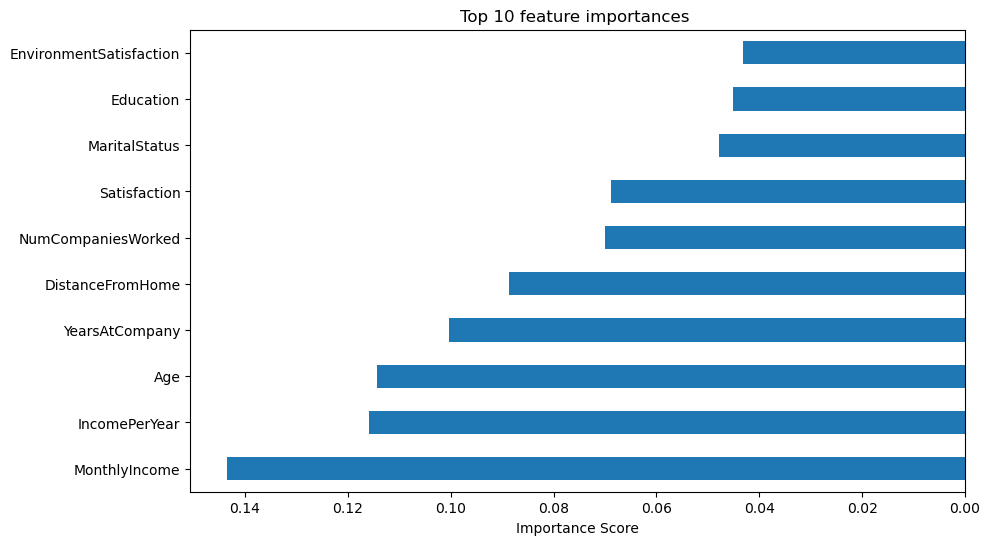

In [153]:
feat_imp.head(10).plot(kind ='barh' , figsize=(10,6))

plt.title('Top 10 feature importances ' )
plt.xlabel('Importance Score')
plt.gca().invert_xaxis()
plt.show()

#### Optimisation of the best performing algorithm 

In [154]:

param_grid = {'lr__C' : [0.01 , 0.1 , 1.0 , 10 , 100]}

grid = GridSearchCV(
    pipeline , 
    param_grid,
    cv = 5 , 
    verbose=1,
    scoring='recall'
)

grid.fit(X,y)

print(f'Best C : {grid.best_params_}')
print(f'Best recall  : {grid.best_score_:.2f}')

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Best C : {'lr__C': 0.01}
Best recall  : 0.68


"GridSearchCV revealed that strong regularization (C=0.01) performed best, suggesting the model benefits from simplicity on this relatively small dataset of 1470 rows. Lower complexity reduces overfitting risk."

#### Final opimised model 

In [155]:
# now we will retrain our model with best C:

model = Pipeline([
    ('scaler' , StandardScaler()),
    ('lr' , LogisticRegression(max_iter=1000,
        C = 0.01,
        random_state=42,
        class_weight='balanced'))
])

model.fit(X_train,y_train)
y_pred_fm = model.predict(X_test)
print(classification_report(y_test , y_pred_fm))

              precision    recall  f1-score   support

           0       0.90      0.66      0.76       247
           1       0.25      0.60      0.35        47

    accuracy                           0.65       294
   macro avg       0.57      0.63      0.56       294
weighted avg       0.79      0.65      0.69       294



#### Final Overview on how all the alogrithms performed 

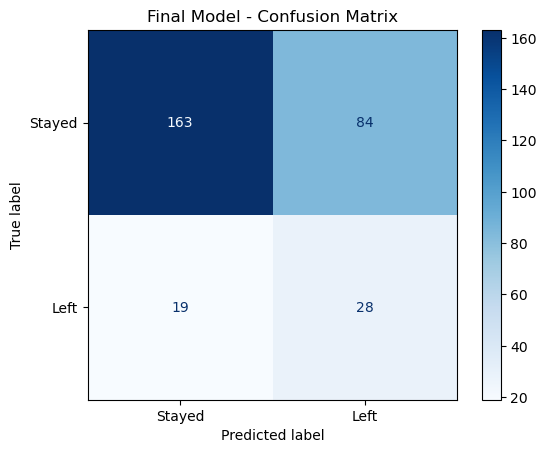

In [156]:
cm = confusion_matrix(y_test , y_pred_fm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm , display_labels=['Stayed' , 'Left'])
disp.plot(cmap='Blues')
plt.title('Final Model - Confusion Matrix')
plt.show()

In [157]:
print(len(X.columns.to_list()))

19


In [159]:
proba = model.predict_proba(X_test)
prediction = model.predict(X_test)
print(proba[1])
print(prediction[1])

[0.62505576 0.37494424]
0


In [160]:
columns = ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
    'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked',
    'WorkLifeBalance', 'YearsAtCompany', 'IncomePerYear', 'Satisfaction',
    'Department_Research & Development', 'Department_Sales',
    'EducationField_Life Sciences', 'EducationField_Marketing',
    'EducationField_Medical', 'EducationField_Other',
    'EducationField_Technical Degree']
test_1 = pd.DataFrame([{
    'Age': 24,
    'DistanceFromHome': 29,
    'Education': 2,
    'EnvironmentSatisfaction': 1,
    'JobSatisfaction': 1,
    'MaritalStatus': 0,  # Single (based on your mapping)
    'MonthlyIncome': 2200,
    'NumCompaniesWorked': 8,
    'WorkLifeBalance': 1,
    'YearsAtCompany': 1,
    'IncomePerYear': 2200/24,   # keep your current feature formula
    'Satisfaction': (1+1+1)/3,  # as per your app
    'Department_Research & Development': 0,
    'Department_Sales': 1,
    'EducationField_Life Sciences': 0,
    'EducationField_Marketing': 1,
    'EducationField_Medical': 0,
    'EducationField_Other': 0,
    'EducationField_Technical Degree': 0
}], columns=columns)

pred_test = model.predict(test_1)
proba_test = model.predict_proba(test_1)
pred_test
proba_test

array([[1.00000000e+000, 4.95301156e-140]])

In [161]:
test_2 = pd.DataFrame([{
    'Age': 28,
    'DistanceFromHome': 15,
    'Education': 2,
    'EnvironmentSatisfaction': 1,
    'JobSatisfaction': 1,
    'MaritalStatus': 0,
    'MonthlyIncome': 2000,
    'NumCompaniesWorked': 3,
    'WorkLifeBalance': 1,
    'YearsAtCompany': 1,
    'IncomePerYear': 2000/28,
    'Satisfaction': (1+1+1)/3,
    'Department_Research & Development': 0,
    'Department_Sales': 1,
    'EducationField_Life Sciences': 0,
    'EducationField_Marketing': 0,
    'EducationField_Medical': 0,
    'EducationField_Other': 0,
    'EducationField_Technical Degree': 0
}], columns=columns)

pred = model.predict(test_2)
proba = model.predict_proba(test_2)
print(f"Prediction: {pred}")
print(f"Probability: {proba}")

Prediction: [0]
Probability: [[1.00000000e+000 1.42772887e-128]]


In [163]:
print(model.classes_)
print(pred_test)
print(proba_test)

[0 1]
[0]
[[1.00000000e+000 4.95301156e-140]]


In [164]:
# Check what the model actually predicts on your test set
print("Predictions on actual test data:")
print(model.predict(X_test)[:30])
print("\nActual values:")
print(y_test.values[:30])

Predictions on actual test data:
[1 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 0 0 0 1 0 1 0 0 1 1 0 0 0]

Actual values:
[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 1]


In [165]:
# Check what the scaler does to your manual input
test_2_scaled = model.named_steps['scaler'].transform(test_2)
print(test_2_scaled)

[[ 2.80000000e+01  1.50000000e+01  2.00000000e+00  1.00000000e+00
   1.00000000e+00  1.05735526e-16  2.00000000e+03  3.00000000e+00
   1.00000000e+00  1.00000000e+00  7.14285714e+01  1.00000000e+00
   1.35945676e-16  1.00000000e+00 -2.41681203e-17 -3.02101503e-17
   5.43782706e-17  9.06304510e-18  5.13572556e-17]]


In [166]:
print(model.named_steps)

{'scaler': StandardScaler(), 'lr': LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42)}


In [167]:
# Step 1: Check scaler is working now
test_2_scaled = model.named_steps['scaler'].transform(test_2)
print("Scaled values:")
print(test_2_scaled)

Scaled values:
[[ 2.80000000e+01  1.50000000e+01  2.00000000e+00  1.00000000e+00
   1.00000000e+00  1.05735526e-16  2.00000000e+03  3.00000000e+00
   1.00000000e+00  1.00000000e+00  7.14285714e+01  1.00000000e+00
   1.35945676e-16  1.00000000e+00 -2.41681203e-17 -3.02101503e-17
   5.43782706e-17  9.06304510e-18  5.13572556e-17]]


In [168]:
scaler = model.named_steps['scaler']
print("Scaler means:", scaler.mean_)
print("Scaler stds:", scaler.scale_)

Scaler means: [-4.22942105e-17 -4.68257330e-17  8.76094360e-17  1.51050752e-17
  1.60113797e-16 -1.05735526e-16 -7.93016446e-17 -5.73992856e-17
 -6.94833458e-17 -1.58603289e-17 -2.47723233e-16  3.44395714e-16
 -1.35945676e-16 -5.89097931e-17  2.41681203e-17  3.02101503e-17
 -5.43782706e-17 -9.06304510e-18 -5.13572556e-17]
Scaler stds: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


This Saved model is trained on scaled data instead of unscaled data that is why the values arent scaled properly.

so in order to a pipeline aligned properly we need to train it on unscaled data only then it is usefull

In [169]:
x_fresh = df.drop('Attrition',axis = 1)
y_fresh = df['Attrition']

X_train_fresh , x_test_fresh ,y_train_fresh , y_test_fresh = train_test_split(
    x_fresh ,
    y_fresh,
    test_size=0.2,
    random_state=42,
    stratify=y_fresh
)

fresh_pipeline = Pipeline([
    ('scaler' , StandardScaler()),
    ('lr' , LogisticRegression(
        C=0.01,
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

fresh_pipeline.fit(X_train_fresh , y_train_fresh)

y_pred_fresh = fresh_pipeline.predict(x_test_fresh)
print(classification_report(y_test_fresh,y_pred_fresh))

              precision    recall  f1-score   support

           0       0.90      0.66      0.76       247
           1       0.25      0.60      0.35        47

    accuracy                           0.65       294
   macro avg       0.57      0.63      0.56       294
weighted avg       0.79      0.65      0.69       294



In [170]:
prediction_fresh = fresh_pipeline.predict(test_2)
probability_fresh = fresh_pipeline.predict_proba(test_2)
prediction_fresh

array([1])

In [171]:
probability_fresh

array([[0.12704805, 0.87295195]])

In [172]:
import joblib
joblib.dump(fresh_pipeline,'final_model.pkl')
print('Final pipeline is saved successfully saved')

Final pipeline is saved successfully saved


In [173]:
df.iloc[2]

Age                                    37.000000
Attrition                               1.000000
DistanceFromHome                        2.000000
Education                               2.000000
EnvironmentSatisfaction                 4.000000
JobSatisfaction                         3.000000
MaritalStatus                           2.000000
MonthlyIncome                        2090.000000
NumCompaniesWorked                      6.000000
WorkLifeBalance                         3.000000
YearsAtCompany                          0.000000
IncomePerYear                          56.486486
Satisfaction                            3.333333
Department_Research & Development       1.000000
Department_Sales                        0.000000
EducationField_Life Sciences            0.000000
EducationField_Marketing                0.000000
EducationField_Medical                  0.000000
EducationField_Other                    1.000000
EducationField_Technical Degree         0.000000
Name: 2, dtype: floa

In [174]:
threshold = 0.30
y_probability = fresh_pipeline.predict_proba(x_test_fresh)[:,1]
y_prediction = np.where(y_probability > threshold , 1 ,0)
print(classification_report(y_test_fresh , y_prediction))

              precision    recall  f1-score   support

           0       0.95      0.28      0.43       247
           1       0.19      0.91      0.32        47

    accuracy                           0.38       294
   macro avg       0.57      0.60      0.38       294
weighted avg       0.83      0.38      0.41       294



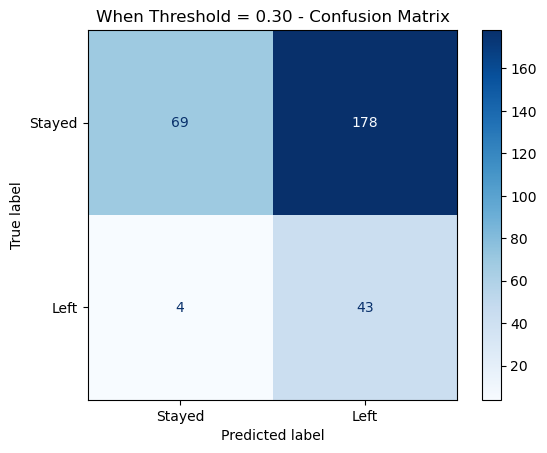

In [175]:
cm = confusion_matrix(y_test_fresh , y_prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm , display_labels=['Stayed' , 'Left'])
disp.plot(cmap='Blues')
plt.title('When Threshold = 0.30 - Confusion Matrix')
plt.show()

In [176]:
final_results = pd.DataFrame({
    'Model' : ['Logistic Regression ' , 'Naive Bayes' , 'SVM' , 'Random Forest ' , 'LR tuned (5 folds)' , 'LR Tuned (c : 0.01)' , 'LR(threshold = 0.35)'],
    'Recall (Quitters)': [0.55 , 0.40 , 0.45 , 0.06, 0.68,0.60,0.91],
    'Precision(Alarms)':[0.25,0.37,0.27,0.33,'-',0.25,0.19],
    'F1 (Quitters)' : [0.33 , 0.38 , 0.34 , 0.11 , '-' , 0.35,0.32],
    'Overall Accuracy'  : [0.65 , 0.79 , 0.72 , 0.83 , '-' , 0.65,0.38],

})
final_results

,Model,Recall (Quitters),Precision(Alarms),F1 (Quitters),Overall Accuracy
0,Logistic Regression,0.55,0.25,0.33,0.65
1,Naive Bayes,0.40,0.37,0.38,0.79
2,SVM,0.45,0.27,0.34,0.72
3,Random Forest,0.06,0.33,0.11,0.83
4,LR tuned (5 folds),0.68,-,-,-
5,LR Tuned (c : 0.01),0.60,0.25,0.35,0.65
6,LR(threshold = 0.35),0.91,0.19,0.32,0.38


## Conclusion

Logistic Regression with C=0.01 and class_weight='balanced' 
was selected as the final model.

**Key Results:**
- Recall (5-fold CV): 0.68 — catches 68% of actual quitters
- Low variance (±0.04) — model generalizes consistently
- Recall (threshold) : 0.91 - catched 91% of actual quitters but poor precision which shows the recall - predicion trade off clearly

**Why Logistic Regression over Random Forest (83% accuracy)?**
Random Forest achieved only 6% Recall for quitters — proving 
accuracy is meaningless on imbalanced datasets. Missing a 
quitter costs recruitment + training expenses. A false alarm 
costs one HR conversation. Recall is the right metric here.

**Feature Engineering Impact:**
Both engineered features (IncomePerYear, SatisfactionScore) 
appeared in top 10 most important features — validating the 
business logic behind creating them.

In [177]:
import sklearn
print(sklearn.__version__)

1.6.1
